In [12]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Function

In [13]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

def resample_cycle(cycle, target_len=30):
    """Resamples a (N x 3) cycle to (target_len x 3)"""
    n_samples, n_features = cycle.shape
    new_cycle = np.zeros((target_len, n_features))
    
    old_x = np.linspace(0, 1, n_samples)
    new_x = np.linspace(0, 1, target_len)
    
    for i in range(n_features):
        new_cycle[:, i] = np.interp(new_x, old_x, cycle[:, i])
    return new_cycle


# Load model

Model parameters loaded from environment_classifier_model_2.npz
Loaded 2 centroids, X_min: [ 5.54940524e-03 -3.00806313e+01 -6.19533539e+00], range_val: [ 3.56485298 39.10421944 10.29013348], window: 90


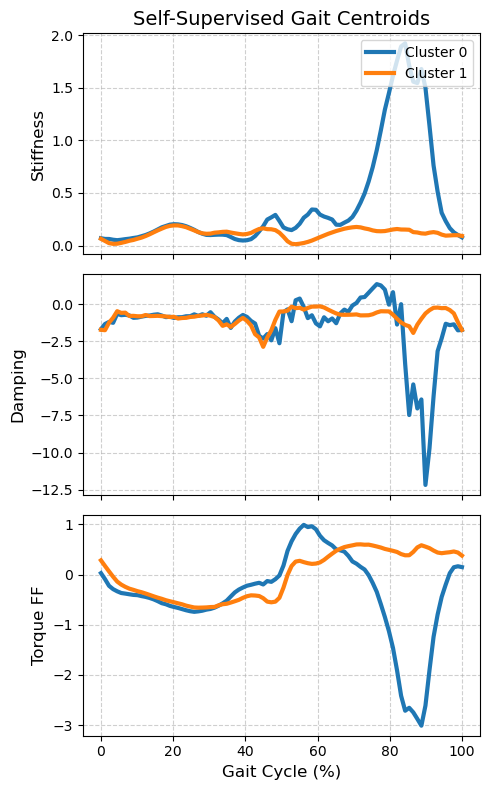

In [14]:
from env_pred import TimeSeriesKMeans

# Create an empty instance and load the pre-trained parameters
controller_model = TimeSeriesKMeans()
controller_model.load_model("environment_classifier_model_2.npz")

controller_model.plot_centroids()

# Test

In [15]:
# transition_1 = remove_specific_cycles(np.load('transition_2.npz', allow_pickle=True), indices_to_remove=[])
transition_1 = remove_specific_cycles(np.load('transition_3.npz', allow_pickle=True), indices_to_remove=[])

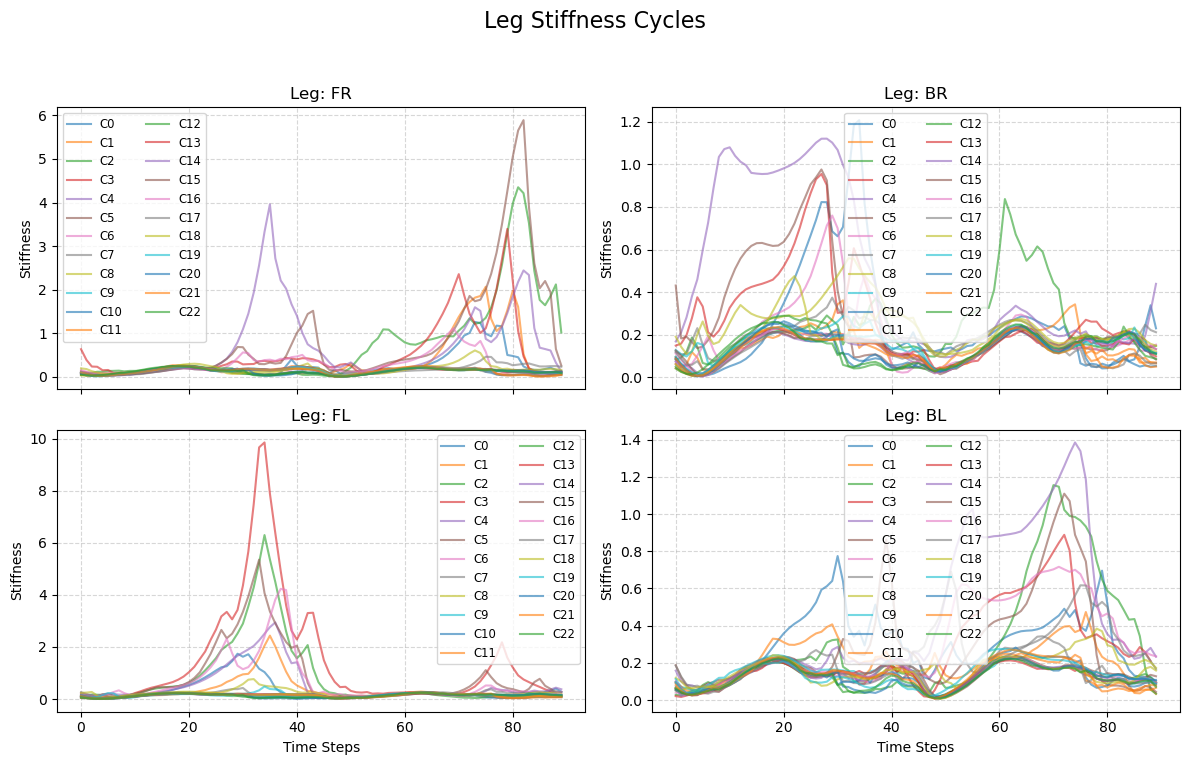

In [16]:
data = transition_1

legs = ['FR', 'BR', 'FL', 'BL'] # Arranged for natural layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, leg in enumerate(legs):
    key = f'stiffness_{leg}'
    if key in data:
        # Plot every cycle in the buffer for this leg
        for j, cycle in enumerate(data[key]):
            axes[i].plot(cycle, alpha=0.6, label=f'C{j}')
        
        axes[i].set_title(f'Leg: {leg}')
        axes[i].set_ylabel('Stiffness')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].legend(fontsize='small', ncol=2)


# Global labels
fig.suptitle('Leg Stiffness Cycles', fontsize=16)
for ax in axes[2:]: ax.set_xlabel('Time Steps')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
X_raw = []
for k, b, tau in zip(transition_1['stiffness_FR'], 
                     transition_1['damping_FR'], 
                     transition_1['torque_feedforward_FR']):
    # Each item is a (Length x 3) matrix
    X_raw.append(np.stack([k, b, tau], axis=1))

# 2. Resample all cycles to the same length (e.g., 30)
X_fixed = [resample_cycle(cycle, target_len=90) for cycle in X_raw]

print(controller_model.range_val)

[ 3.56485298 39.10421944 10.29013348]


In [18]:
results = []

# Iterate through each resampled cycle in your transition dataset
for i, cycle in enumerate(X_fixed):
    # cycle is already (90, 3), matching your target_len
    cluster_id, uncertainty = controller_model.predict(cycle)
    
    # Store results for analysis
    results.append({
        'cycle_index': i,
        'predicted_env': f'Cluster id: {cluster_id}', # verify which ID is which
        'uncertainty': uncertainty
    })

# Display a few results
for res in results:
    print(f"Cycle {res['cycle_index']}: {res['predicted_env']} (Uncertainty: {res['uncertainty']:.3f})")

Cycle 0: Cluster id: 0 (Uncertainty: 0.809)
Cycle 1: Cluster id: 0 (Uncertainty: 0.609)
Cycle 2: Cluster id: 0 (Uncertainty: 0.794)
Cycle 3: Cluster id: 0 (Uncertainty: 0.769)
Cycle 4: Cluster id: 0 (Uncertainty: 0.822)
Cycle 5: Cluster id: 0 (Uncertainty: 0.761)
Cycle 6: Cluster id: 1 (Uncertainty: 0.904)
Cycle 7: Cluster id: 1 (Uncertainty: 0.455)
Cycle 8: Cluster id: 1 (Uncertainty: 0.594)
Cycle 9: Cluster id: 1 (Uncertainty: 0.199)
Cycle 10: Cluster id: 1 (Uncertainty: 0.257)
Cycle 11: Cluster id: 1 (Uncertainty: 0.266)
Cycle 12: Cluster id: 1 (Uncertainty: 0.218)
Cycle 13: Cluster id: 1 (Uncertainty: 0.171)
Cycle 14: Cluster id: 1 (Uncertainty: 0.171)
Cycle 15: Cluster id: 1 (Uncertainty: 0.203)
Cycle 16: Cluster id: 1 (Uncertainty: 0.201)
Cycle 17: Cluster id: 1 (Uncertainty: 0.243)
Cycle 18: Cluster id: 1 (Uncertainty: 0.250)
Cycle 19: Cluster id: 1 (Uncertainty: 0.174)
Cycle 20: Cluster id: 1 (Uncertainty: 0.237)
Cycle 21: Cluster id: 1 (Uncertainty: 0.232)
Cycle 22: Cluster id

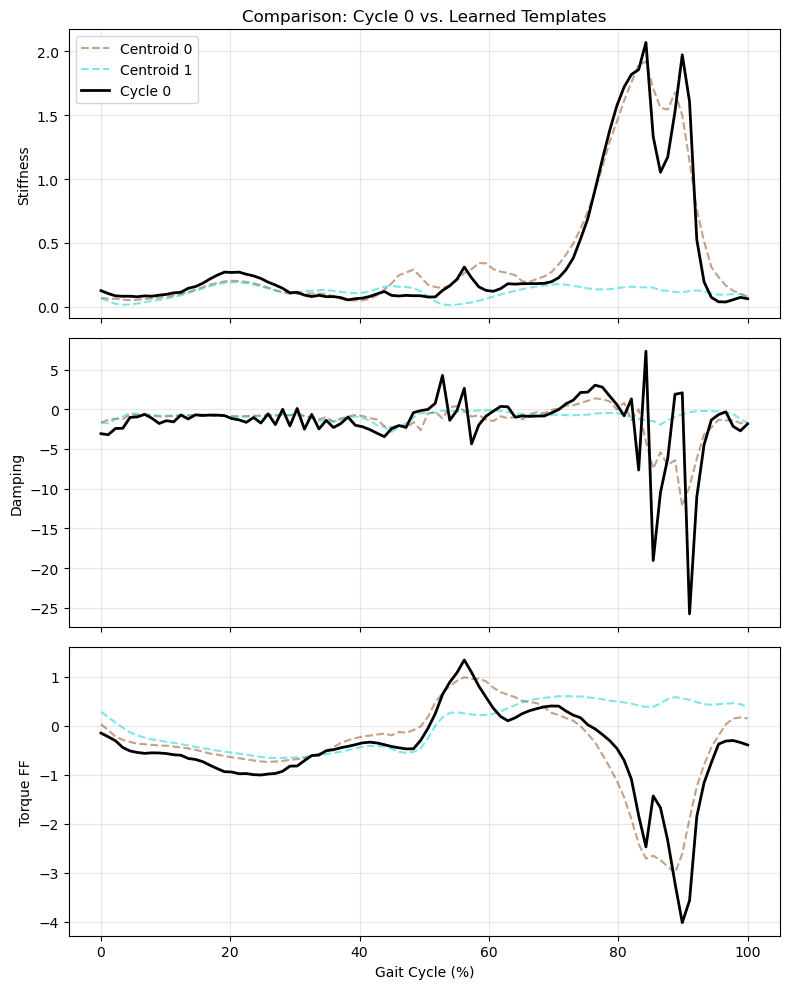

In [19]:
def plot_cycle_vs_centroids(model, live_cycle, cycle_idx=0):
    # 1. Rescale centroids and live cycle for physical comparison
    rescaled_centroids = [c * model.range_val + model.X_min for c in model.centroids]
    # Create the plot
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    feature_names = ['Stiffness', 'Damping', 'Torque FF']
    colors = ['#8B4513', '#00CED1'] # Brown, Cyan
    
    t = np.linspace(0, 100, live_cycle.shape[0])

    for feat_idx in range(3):
        # Plot Centroid 0
        axes[feat_idx].plot(t, rescaled_centroids[0][:, feat_idx], 
                            color=colors[0], linestyle='--', alpha=0.5, label='Centroid 0')
        
        # Plot Centroid 1
        axes[feat_idx].plot(t, rescaled_centroids[1][:, feat_idx], 
                            color=colors[1], linestyle='--', alpha=0.5, label='Centroid 1')
        
        # Plot the Actual Cycle
        axes[feat_idx].plot(t, live_cycle[:, feat_idx], 
                            color='black', linewidth=2, label=f'Cycle {cycle_idx}')
        
        axes[feat_idx].set_ylabel(feature_names[feat_idx])
        axes[feat_idx].grid(True, alpha=0.3)

    axes[0].set_title(f"Comparison: Cycle {cycle_idx} vs. Learned Templates")
    axes[0].legend()
    plt.xlabel("Gait Cycle (%)")
    plt.tight_layout()
    plt.show()

plot_cycle_vs_centroids(controller_model, X_fixed[1], cycle_idx=0)